# Fig. 7B-D: Entropy variation across PFA between repeating the same beam aim or move to another grid

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.font_manager as fm


In [2]:
# Path to save figs and data for figs
path_fig = Path("../figs")
path_data = Path("../simulations")
path_csv = path_data / "fig_7BCD_h_est_pm1e-03"

In [3]:
cr_all = list(range(5, 11))
br_all = [1, 2]

In [4]:
cmap_br1 = matplotlib.colormaps["Blues_r"]
colors_br1 = [cmap_br1(c / (len(cr_all) + 1)) for c in range(len(cr_all))]
cmap_br2 = matplotlib.colormaps["Reds_r"]
colors_br2 = [cmap_br2(c / (len(cr_all) + 1)) for c in range(len(cr_all))]

In [5]:
# Load grid number and crossover values
df_grid = pd.read_csv(path_data / "fig_7BCD_num_grid.csv", index_col=0)
df_x = pd.read_csv(path_data / "fig_7BCD_pfa_crossover_pm1e-03.csv", index_col=0)

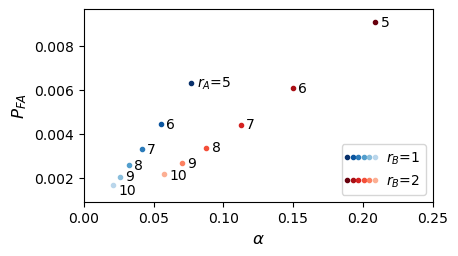

In [6]:
# crossover values vs alpha
fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

cr_colors = [colors_br1, colors_br2]
for cr_seq, cr in enumerate(list(range(5, 11))):
    for br_seq, br in enumerate([1, 2]):
        df_grid_filt = df_grid[(df_grid["cr"]==cr) & (df_grid["br"]==br)]
        df_x_filt = df_x[(df_x["cr"]==cr) & (df_x["br"]==br)]

        x = (df_grid_filt["num_grids_in_beam"]/df_grid_filt["num_grids_in_space"]).values
        y = df_x_filt["pfa_crossover_value"].values
        ax.plot(x, y ,marker=".", color=cr_colors[br_seq][cr_seq])

        # Annotate with cr value
        s = rf"$r_A$={cr}" if cr_seq==0 and br_seq==0 else f"{cr}"
        if cr==10:
            offset = (4, -4) if br==1 else (4, -1)
        else:
            offset = (4, 0)
        # offset = (3.5, -3) if cr==10 and br==1 else (3.5, 0)
        # offset = (3.5, -3) if cr==10 and br==2 else (3.5, 0)
        ax.annotate(
            s, (x, y),
            textcoords="offset points",
            xytext=offset,  # offset from point
            fontsize=10,
            color="k",
            va="center"
        )

ylim = ax.get_ylim()
ax.set_ylim(ylim[0]-0.0004, ylim[1]+0.0002)
ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel(r"$P_{FA}$", fontsize=12)

# # make legend
# ax.plot(np.nan, np.nan, color=br_colors[0], label=r"$r_B$=1")
# ax.plot(np.nan, np.nan, color=br_colors[1], label=r"$r_B$=2")
# ax.legend(loc="lower right", fontsize=10)

# Create legend with 2 rows (one for each br), each showing all 5 cr markers
legend_elements = []
legend_labels = []

# Row 1: br=1 with all cr values
br1_handles = tuple([Line2D([0], [0], color=colors_br1[seq], marker='.', 
                            markersize=6, linestyle='') for seq in range(len(cr_all))])
legend_elements.append(br1_handles)
legend_labels.append(r"$r_B$=1")

# Row 2: br=2 with all cr values
br2_handles = tuple([Line2D([0], [0], color=colors_br2[seq], marker='.', 
                            markersize=6, linestyle='') for seq in range(len(cr_all))])
legend_elements.append(br2_handles)
legend_labels.append(r"$r_B$=2")

ax.legend(
    legend_elements,
    legend_labels,
    handler_map={tuple: matplotlib.legend_handler.HandlerTuple(ndivide=None)},
    loc="lower right",
    fontsize=10,
)

ax.set_xlim (0, 0.25)

plt.show()

fig.savefig(path_fig / "fig_7D_repeat_beam_aim_alpha_pfa.png", dpi=300, bbox_inches="tight")

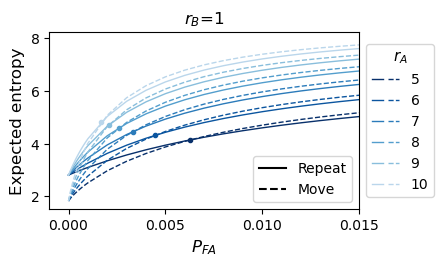

In [7]:
# br=1 curves
fig, ax = plt.subplots(1, 1, figsize=(4, 2.3))

br = 1
for seq, cr in enumerate(cr_all):
    df_h = pd.read_csv(path_csv / f"cr{cr}_br{br}_pfa_full_range.csv", index_col=0)
    ax.plot(df_h["pfa"], df_h["h_est_c"], color=colors_br1[seq], ls="-", lw=1)
    ax.plot(df_h["pfa"], df_h["h_est_n"], color=colors_br1[seq], ls="--", lw=1)
    df_x_filt = df_x[(df_x["cr"]==cr) & (df_x["br"]==br)]
    ax.plot(
        df_x_filt["pfa_crossover_value"], df_x_filt["h_est_n_crossover_value"],
        color=colors_br1[seq], marker="."
    )
    ax.set_xticks(np.arange(0, 0.022, 0.005))
ax.set_xlabel(r"$P_{FA}$", fontsize=12)
ax.set_ylabel("Expected entropy", fontsize=12)
ax.plot(np.nan, np.nan, ls="-", color="k", label="Repeat")
ax.plot(np.nan, np.nan, ls="--", color="k", label="Move")
legend1 = ax.legend(loc="lower right")
ax.add_artist(legend1)

# make legend
legend_elements = []
for seq, cr in enumerate(cr_all):
    # Create a tuple of (solid line, dashed line) for each cr
    legend_elements.append((
        Line2D([0], [0], color=colors_br1[seq], ls='-', lw=1),
        Line2D([0], [0], color=colors_br1[seq], ls='--', lw=1)
    ))

# Add legend with tuple handles (will show both styles)
ax.legend(
    legend_elements, 
    cr_all,
    handler_map={tuple: matplotlib.legend_handler.HandlerTuple(ndivide=None)},
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title=r"$r_A$",
    title_fontproperties=fm.FontProperties(weight="bold", size=11),
)
ax.set_title(r"$r_B$=1", fontsize=12)
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], 0.015)

fig.savefig(path_fig / "fig_7B_repeat_beam_aim_br1.png", dpi=300, bbox_inches="tight")

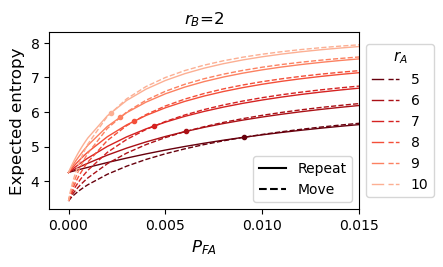

In [8]:
# br=2 curves
fig, ax = plt.subplots(1, 1, figsize=(4, 2.3))

br = 2
for seq, cr in enumerate(cr_all):
    df_h = pd.read_csv(path_csv / f"cr{cr}_br{br}_pfa_full_range.csv", index_col=0)
    ax.plot(df_h["pfa"], df_h["h_est_c"], color=colors_br2[seq], ls="-", lw=1)
    ax.plot(df_h["pfa"], df_h["h_est_n"], color=colors_br2[seq], ls="--", lw=1)
    df_x_filt = df_x[(df_x["cr"]==cr) & (df_x["br"]==br)]
    ax.plot(
        df_x_filt["pfa_crossover_value"], df_x_filt["h_est_n_crossover_value"],
        color=colors_br2[seq], marker="."
    )
    ax.set_xticks(np.arange(0, 0.022, 0.005))
ax.set_xlabel(r"$P_{FA}$", fontsize=12)
ax.set_ylabel("Expected entropy", fontsize=12)
ax.plot(np.nan, np.nan, ls="-", color="k", label="Repeat")
ax.plot(np.nan, np.nan, ls="--", color="k", label="Move")
legend1 = ax.legend(loc="lower right")
ax.add_artist(legend1)

# make legend
legend_elements = []
for seq, cr in enumerate(cr_all):
    # Create a tuple of (solid line, dashed line) for each cr
    legend_elements.append((
        Line2D([0], [0], color=colors_br2[seq], ls='-', lw=1),
        Line2D([0], [0], color=colors_br2[seq], ls='--', lw=1)
    ))

# Add legend with tuple handles (will show both styles)
ax.legend(
    legend_elements, 
    cr_all,
    handler_map={tuple: matplotlib.legend_handler.HandlerTuple(ndivide=None)},
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title=r"$r_A$",
    title_fontproperties=fm.FontProperties(weight="bold", size=11),
)
ax.set_title(r"$r_B$=2", fontsize=12)
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], 0.015)

fig.savefig(path_fig / "fig_7C_repeat_beam_aim_br2.png", dpi=300, bbox_inches="tight")